# 01 — Data Discovery & Profiling

**Proyecto:** Clasificación de ventana terapéutica en ACV isquémico — Fundación Valle del Lilí.
**Fase:** 1 — Data Discovery.
**Documento maestro:** [`../agent.md`](../agent.md) (releer si vuelves después de >1 día).

## Objetivo de este notebook

1. **Confirmar con código vivo** todos los hallazgos del §3 de `agent.md`.
2. **Auditar el grano** de los datos: paciente vs slice.
3. **Cuantificar la realidad del N pequeño** (74 pacientes únicos) — esto rige la arquitectura.
4. **Identificar leakage explícito** (`Evolution Time` → target).
5. **Detectar drift train↔test** que pueda sabotear el modelo silenciosamente.
6. **Producir artefactos versionables**: figuras en `reports/figures/`, hallazgos en `docs/eda_findings.md`.

## Lo que NO hacemos aquí

- Modelado.
- Imputación o limpieza definitiva — eso vive en `staging` (Fase 2/3).
- EDA inferencial pesado (Mann-Whitney, FDR) — eso vive en notebook 03 (Fase 4).

## Cómo leer este notebook

Cada sección numerada tiene la forma: **markdown explicativo → código → output → interpretación corta**. La interpretación final está al pie en *§ 8 Summary findings*.

## Setup

Importamos lo estrictamente necesario. Mantenemos el notebook **reproducible**: la semilla y los paths vienen del módulo `acv.config` para que cualquier cambio se propague sin tocar el notebook.

In [ ]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from acv.config import settings

RAW = settings.project_root / "data" / "raw"
FIG = settings.project_root / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

np.random.seed(settings.random_seed)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print("project_root:", settings.project_root)
print("raw dir     :", RAW)
print("figures dir :", FIG)

project_root: C:\Users\andre\Documents\ischemic_stroke_prevention
raw dir     : C:\Users\andre\Documents\ischemic_stroke_prevention\data\raw
figures dir : C:\Users\andre\Documents\ischemic_stroke_prevention\reports\figures


## § 1 — Carga & anatomía de columnas

Cargamos ambos CSV y los unimos con una columna `dataset_origin ∈ {train, test}`. Esto nos permite hacer todo el EDA con un único DataFrame y comparar distribuciones train↔test sin escribir código duplicado.

**Detalle clínico importante:** en la fuente, `NIHSS` y `ASPECTS` pueden llegar como `""` (string vacío). Forzamos su parseo numérico para que `NaN` aparezca explícitamente y podamos contar faltantes con honestidad.

In [ ]:
def load_split(path: Path, origin: str) -> pd.DataFrame:
    df = pd.read_csv(path, dtype={"ID": str})
    df["dataset_origin"] = origin
    for col in ("NIHSS", "ASPECTS", "Evolution Time"):
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


train = load_split(RAW / "acv_clasif_train.csv", "train")
test = load_split(RAW / "acv_clasif_test.csv", "test")
df = pd.concat([train, test], ignore_index=True)

print(f"train shape: {train.shape}")
print(f"test  shape: {test.shape}")
print(f"union shape: {df.shape}")
print()
print("Column families (count by prefix):")
families = {
    "shape2D": [c for c in df.columns if c.startswith("original_shape2D_")],
    "firstorder": [c for c in df.columns if c.startswith("original_firstorder_")],
    "glcm": [c for c in df.columns if c.startswith("original_glcm_")],
    "glszm": [c for c in df.columns if c.startswith("original_glszm_")],
}
for k, v in families.items():
    print(f"  {k:11s}: {len(v):2d} columns")
non_radiomic = [c for c in df.columns if not c.startswith("original_")]
print(f"  non-radiomic:", non_radiomic)

train shape: (1998, 72)
test  shape: (822, 72)
union shape: (2820, 72)

Column families (count by prefix):
  shape2D    :  8 columns
  firstorder : 17 columns
  glcm       : 23 columns
  glszm      : 16 columns
  non-radiomic: ['ID', 'Patien Age in Study', 'Patient Sex', 'NIHSS', 'Evolution Time', 'ASPECTS', 'Evolution Time_Clas', 'dataset_origin']


## § 2 — Auditoría del grano: slice vs paciente

Cada fila del CSV es **un slice de TC**, no un paciente. Un mismo `ID` aparece muchas veces porque corresponden a cortes axiales del mismo estudio. Esto es **lo más importante de toda la Fase 1**: si se nos olvida, cualquier validación cruzada será fraudulenta (porque slices del mismo paciente se filtrarían entre train y validación).

Lo que confirmamos:
- ¿Cuántos pacientes únicos hay en train y en test?
- ¿Cuántos slices por paciente?
- ¿Hay solapamiento de pacientes entre train y test? (debería ser 0)

Grain audit:
                rows  unique_patients  slices_per_patient_mean
dataset_origin                                                
test             822               19                  43.2600
train           1998               55                  36.3300

Slices per patient — distribution:
                 count    mean     std    min     10%     50%     90%      max
dataset_origin                                                                
test           19.0000 43.3000 29.6000 7.0000 12.0000 31.0000 84.2000  90.0000
train          55.0000 36.3000 27.5000 2.0000  6.6000 29.0000 75.8000 117.0000

Train↔test patient overlap: 0  (must be 0)


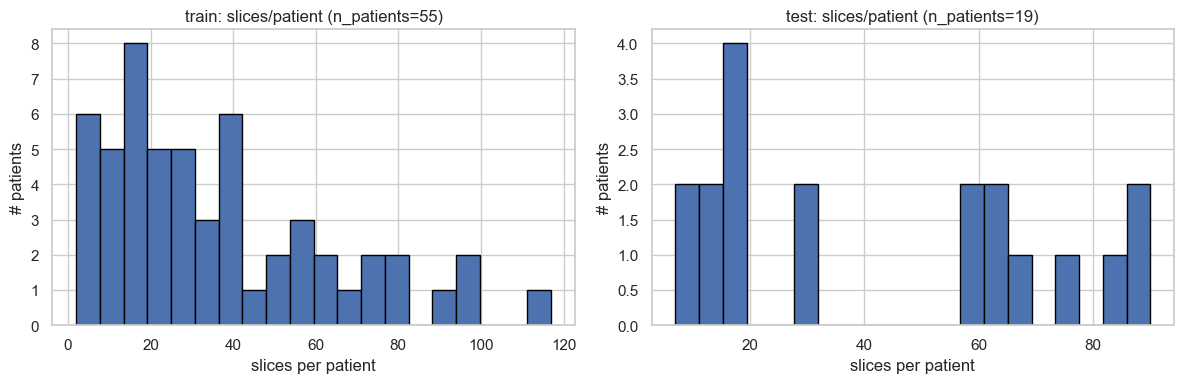

In [ ]:
grain = (
    df.groupby("dataset_origin")
    .agg(
        rows=("ID", "size"),
        unique_patients=("ID", "nunique"),
    )
    .assign(slices_per_patient_mean=lambda x: (x["rows"] / x["unique_patients"]).round(2))
)
print("Grain audit:")
print(grain)
print()

slices_per_patient = df.groupby(["dataset_origin", "ID"]).size().reset_index(name="n_slices")
print("Slices per patient — distribution:")
print(
    slices_per_patient.groupby("dataset_origin")["n_slices"]
    .describe(percentiles=[0.1, 0.5, 0.9])
    .round(1)
)
print()

train_ids = set(train["ID"].unique())
test_ids = set(test["ID"].unique())
overlap = train_ids & test_ids
print(f"Train↔test patient overlap: {len(overlap)}  (must be 0)")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for i, origin in enumerate(["train", "test"]):
    s = slices_per_patient.loc[slices_per_patient["dataset_origin"] == origin, "n_slices"]
    ax[i].hist(s, bins=20, edgecolor="black")
    ax[i].set_title(f"{origin}: slices/patient (n_patients={s.size})")
    ax[i].set_xlabel("slices per patient")
    ax[i].set_ylabel("# patients")
plt.tight_layout()
plt.savefig(FIG / "01_slices_per_patient.png", dpi=120)
plt.show()

## § 3 — Distribución del target en ambos granos

Calculamos `Evolution Time_Clas` (`0` = ≤4.5 h elegible, `1` = >4.5 h) en dos vistas:

- **Slice-level**: lo que ves si haces `value_counts()` en el CSV. Es engañoso porque pacientes con más slices "pesan más".
- **Patient-level**: el grano clínicamente relevante. Validamos también la **integridad** del target — no puede haber un paciente con dos targets distintos (sería una inconsistencia de la fuente).

In [ ]:
target_col = "Evolution Time_Clas"

print("Slice-level target distribution:")
print(
    df.groupby("dataset_origin")[target_col]
    .value_counts(normalize=False)
    .unstack(fill_value=0)
    .rename(columns={0: "class_0 (<=4.5h)", 1: "class_1 (>4.5h)"})
)
print()

patient_target = (
    df.groupby(["dataset_origin", "ID"])[target_col]
    .nunique()
    .reset_index(name="distinct_targets")
)
inconsistent = patient_target[patient_target["distinct_targets"] > 1]
print(f"Patients with inconsistent target (must be 0): {len(inconsistent)}")
if len(inconsistent):
    print(inconsistent.head())

patient_class = df.groupby(["dataset_origin", "ID"])[target_col].first().reset_index()
print()
print("Patient-level target distribution:")
print(
    patient_class.groupby("dataset_origin")[target_col]
    .value_counts()
    .unstack(fill_value=0)
    .rename(columns={0: "class_0 (<=4.5h)", 1: "class_1 (>4.5h)"})
)
print()
print("Patient-level class balance (proportion):")
print(
    patient_class.groupby("dataset_origin")[target_col]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .round(3)
)

Slice-level target distribution:
Evolution Time_Clas  class_0 (<=4.5h)  class_1 (>4.5h)
dataset_origin                                        
test                              454              368
train                            1238              760

Patients with inconsistent target (must be 0): 0

Patient-level target distribution:
Evolution Time_Clas  class_0 (<=4.5h)  class_1 (>4.5h)
dataset_origin                                        
test                               11                8
train                              39               16

Patient-level class balance (proportion):
Evolution Time_Clas      0      1
dataset_origin                   
test                0.5790 0.4210
train               0.7090 0.2910


## § 4 — Auditoría de faltantes (slice-level)

Las columnas radiómicas no deberían tener nulos (PyRadiomics emite valores siempre que la máscara tenga al menos un voxel). Los nulos clínicos (`NIHSS`, `ASPECTS`) son los que importan.

**Regla clínica:** ese faltante normalmente significa que el escore no se calculó (paciente inconsciente, registro tardío, turno nocturno). Es un *Missing At Random* clínicamente informado — **no se borra**, se imputa con un *missing indicator* en Fase 5.

In [ ]:
missing = (
    df.groupby("dataset_origin")
    .apply(lambda g: g.isna().sum().loc[lambda s: s > 0])
    .unstack(fill_value=0)
    .T.astype(int)
)
print("Columns with missing values (slice-level):")
print(missing)
print()

n_train = train.shape[0]
n_test = test.shape[0]
print("Missing rate (%):")
print(
    missing.assign(
        train_pct=lambda x: (x["train"] / n_train * 100).round(1),
        test_pct=lambda x: (x["test"] / n_test * 100).round(1),
    )[["train", "train_pct", "test", "test_pct"]]
)
print()

print("Missingness by target class (train, NIHSS & ASPECTS):")
for col in ("NIHSS", "ASPECTS"):
    rates = (
        train.assign(_is_na=train[col].isna())
        .groupby(target_col)["_is_na"]
        .mean()
        .round(3)
    )
    print(f"  {col}: P(missing | class) = {rates.to_dict()}")

Columns with missing values (slice-level):
dataset_origin  test  train
ASPECTS          159    169
NIHSS              0    198

Missing rate (%):
dataset_origin  train  train_pct  test  test_pct
ASPECTS           169     8.5000   159   19.3000
NIHSS             198     9.9000     0    0.0000

Missingness by target class (train, NIHSS & ASPECTS):
  NIHSS: P(missing | class) = {0: 0.036, 1: 0.201}
  ASPECTS: P(missing | class) = {0: 0.093, 1: 0.071}


C:\Users\andre\AppData\Local\Temp\ipykernel_11488\263935328.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.isna().sum().loc[lambda s: s > 0])


## § 5 — Auditoría de unidades + alerta de leakage en `Evolution Time`

El nombre `Evolution Time` no dice la unidad. La ventana terapéutica clínica es de **4.5 horas**. Pero en la fuente vemos valores como `Evolution Time = 90` con `class = 0` ("≤ ventana"), lo cual es **incompatible con horas** (90 h > 4.5 h ⇒ debería ser clase 1).

Hipótesis a verificar: la columna está en **minutos**. Si es así, el cutoff equivalente sería `270 min = 4.5 h × 60`. Probamos varios cortes posibles y vemos cuál reproduce el target a ~100%:

Distribución de Evolution Time POR CLASE (unidad aún desconocida):
                        count     mean      std      min      25%      50%      75%       max
Evolution Time_Clas                                                                          
0                   1692.0000 152.4900  68.1600  15.0000 120.0000 120.0000 210.0000  270.0000
1                   1128.0000 566.3900 285.6500 280.0000 360.0000 540.0000 600.0000 1560.0000

Probando cutoffs candidatos:
  hours_cutoff_4.5               -> agreement with target =  40.00%
  minutes_cutoff_270             -> agreement with target = 100.00%
  tenths_of_hour_cutoff_45       -> agreement with target =  41.91%

Búsqueda fina del cutoff que maximiza acuerdo:
  best cutoff = 271.21 | agreement = 100.00%

Conclusión: la columna `Evolution Time` está en MINUTES.
  -> equivalente clínico: cutoff = 271.21 minutes (4.52 h)

Columns banned from feature set: ['Evolution Time']
Razón: Evolution Time es la base aritmética del target -> le

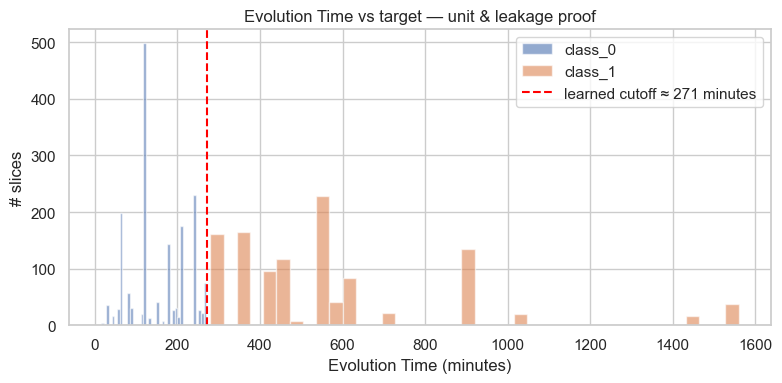

In [ ]:
evo = df[["dataset_origin", "Evolution Time", target_col]].dropna().copy()
print("Distribución de Evolution Time POR CLASE (unidad aún desconocida):")
print(evo.groupby(target_col)["Evolution Time"].describe().round(2))
print()

candidate_cutoffs = {
    "hours_cutoff_4.5": 4.5,
    "minutes_cutoff_270": 270.0,
    "tenths_of_hour_cutoff_45": 45.0,
}
print("Probando cutoffs candidatos:")
for name, cut in candidate_cutoffs.items():
    derived = (evo["Evolution Time"] > cut).astype(int)
    agree = (derived == evo[target_col]).mean()
    print(f"  {name:30s} -> agreement with target = {agree*100:6.2f}%")
print()

print("Búsqueda fina del cutoff que maximiza acuerdo:")
grid = np.linspace(evo["Evolution Time"].min(), evo["Evolution Time"].max(), 200)
agreements = [((evo["Evolution Time"] > c).astype(int) == evo[target_col]).mean() for c in grid]
best_idx = int(np.argmax(agreements))
best_cut, best_agree = grid[best_idx], agreements[best_idx]
print(f"  best cutoff = {best_cut:.2f} | agreement = {best_agree*100:.2f}%")

UNIT = "minutes" if abs(best_cut - 270) < abs(best_cut - 4.5) else "hours"
print(f"\nConclusión: la columna `Evolution Time` está en {UNIT.upper()}.")
print(
    "  -> equivalente clínico: cutoff = "
    f"{best_cut:.2f} {UNIT} ({best_cut/60:.2f} h)" if UNIT == "minutes"
    else f"  -> equivalente clínico: cutoff = {best_cut:.2f} {UNIT}"
)

LEAKAGE_COLS = ["Evolution Time"]
print("\nColumns banned from feature set:", LEAKAGE_COLS)
print("Razón: Evolution Time es la base aritmética del target -> leakage directo.")

fig, ax = plt.subplots(figsize=(8, 4))
for cls, grp in evo.groupby(target_col):
    ax.hist(grp["Evolution Time"], bins=40, alpha=0.6, label=f"class_{cls}")
ax.axvline(best_cut, color="red", linestyle="--", label=f"learned cutoff ≈ {best_cut:.0f} {UNIT}")
ax.set_xlabel(f"Evolution Time ({UNIT})")
ax.set_ylabel("# slices")
ax.set_title("Evolution Time vs target — unit & leakage proof")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "02_leakage_evolution_time.png", dpi=120)
plt.show()

## § 6 — Drift demográfico train ↔ test

El §3 del `agent.md` advierte que train es 61% femenino mientras test es 64% masculino. Antes de modelar, cuantificamos formalmente el drift:

- **Sexo** (categórica): test de chi² de independencia. Si `p < 0.01` hay drift estadísticamente significativo.
- **Edad** (continua): test de Kolmogorov–Smirnov sobre las distribuciones. Hipótesis nula = misma distribución.

El drift no es razón para cancelar el proyecto; sí es razón para **reportar performance por subgrupo** en Fase 6 y vigilar gaps.

Sex distribution (patient-level):
sex              F   M
dataset_origin        
test             8  11
train           32  23
  chi2 = 0.894 | dof = 1 | p = 0.3445
  drift?  no significant drift detected

Age (patient-level): train n=55, test n=19
  train: mean=69.5, std=15.2, median=73
  test : mean=62.8, std=16.6, median=63
  KS = 0.310 | p = 0.1038
  drift?  no significant drift detected


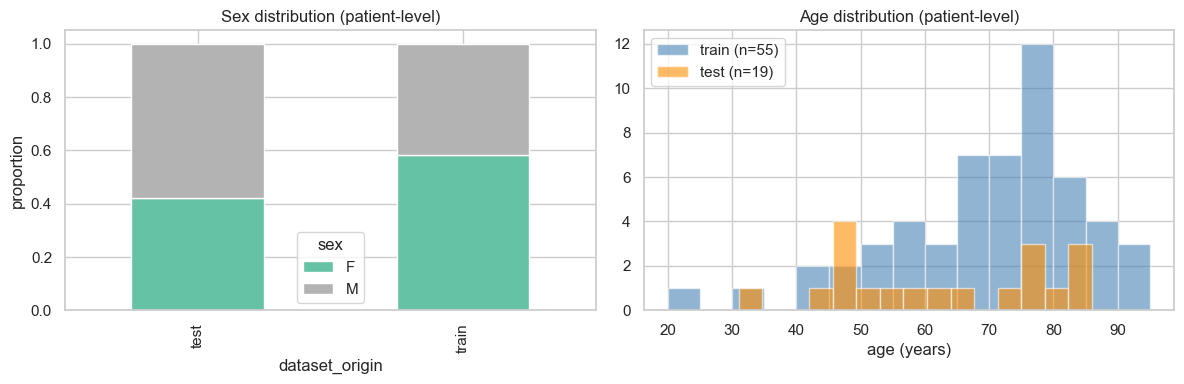

In [ ]:
patient_demo = (
    df.groupby(["dataset_origin", "ID"])
    .agg(sex=("Patient Sex", "first"), age=("Patien Age in Study", "first"))
    .reset_index()
)

sex_tab = pd.crosstab(patient_demo["dataset_origin"], patient_demo["sex"])
print("Sex distribution (patient-level):")
print(sex_tab)
chi2, p_sex, dof, _ = stats.chi2_contingency(sex_tab)
print(f"  chi2 = {chi2:.3f} | dof = {dof} | p = {p_sex:.4f}")
print(f"  drift?  {'YES (p<0.01)' if p_sex < 0.01 else 'no significant drift detected'}")
print()

age_train = patient_demo.loc[patient_demo["dataset_origin"] == "train", "age"].dropna()
age_test = patient_demo.loc[patient_demo["dataset_origin"] == "test", "age"].dropna()
print(f"Age (patient-level): train n={age_train.size}, test n={age_test.size}")
print(f"  train: mean={age_train.mean():.1f}, std={age_train.std():.1f}, median={age_train.median():.0f}")
print(f"  test : mean={age_test.mean():.1f}, std={age_test.std():.1f}, median={age_test.median():.0f}")
ks_stat, p_age = stats.ks_2samp(age_train, age_test)
print(f"  KS = {ks_stat:.3f} | p = {p_age:.4f}")
print(f"  drift?  {'YES (p<0.01)' if p_age < 0.01 else 'no significant drift detected'}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sex_tab_pct = sex_tab.div(sex_tab.sum(axis=1), axis=0)
sex_tab_pct.plot(kind="bar", stacked=True, ax=ax[0], colormap="Set2")
ax[0].set_title("Sex distribution (patient-level)")
ax[0].set_ylabel("proportion")
ax[0].legend(title="sex")
for origin, color in [("train", "steelblue"), ("test", "darkorange")]:
    s = patient_demo.loc[patient_demo["dataset_origin"] == origin, "age"]
    ax[1].hist(s, bins=15, alpha=0.6, label=f"{origin} (n={s.size})", color=color)
ax[1].set_title("Age distribution (patient-level)")
ax[1].set_xlabel("age (years)")
ax[1].legend()
plt.tight_layout()
plt.savefig(FIG / "03_demographic_drift.png", dpi=120)
plt.show()

## § 7 — Sanity check de outliers radiómicos

No estamos haciendo limpieza definitiva (eso vive en `staging`), pero sí queremos detectar **valores manifiestamente imposibles** (negativos donde no deberían existir, NaN inesperados, ceros sospechosos). Usamos el criterio de Tukey (IQR × 1.5) sobre algunas features representativas — un proxy para entender cuán pesadas son las colas.

Sanity check on probe radiomic features:
                                     min        max      mean  n_null  n_negative  n_zero  outlier_rate_iqr
original_shape2D_MeshSurface     35.5000 33723.0000 6976.4573       0           0       0            0.0090
original_shape2D_MaximumDiameter  8.0000   325.8481  140.7640       0           0       0            0.0000
original_shape2D_Sphericity       0.3141     0.9474    0.6910       0           0       0            0.0000
original_firstorder_Mean         18.0401   118.6554   29.2140       0           0       0            0.0250
original_firstorder_Entropy       0.0188     2.7822    0.7712       0           0       0            0.0070
original_glcm_Contrast            0.0019     2.7965    0.1642       0           0       0            0.0200
original_glszm_ZoneEntropy        1.0000     7.1897    4.3157       0           0       0            0.0260


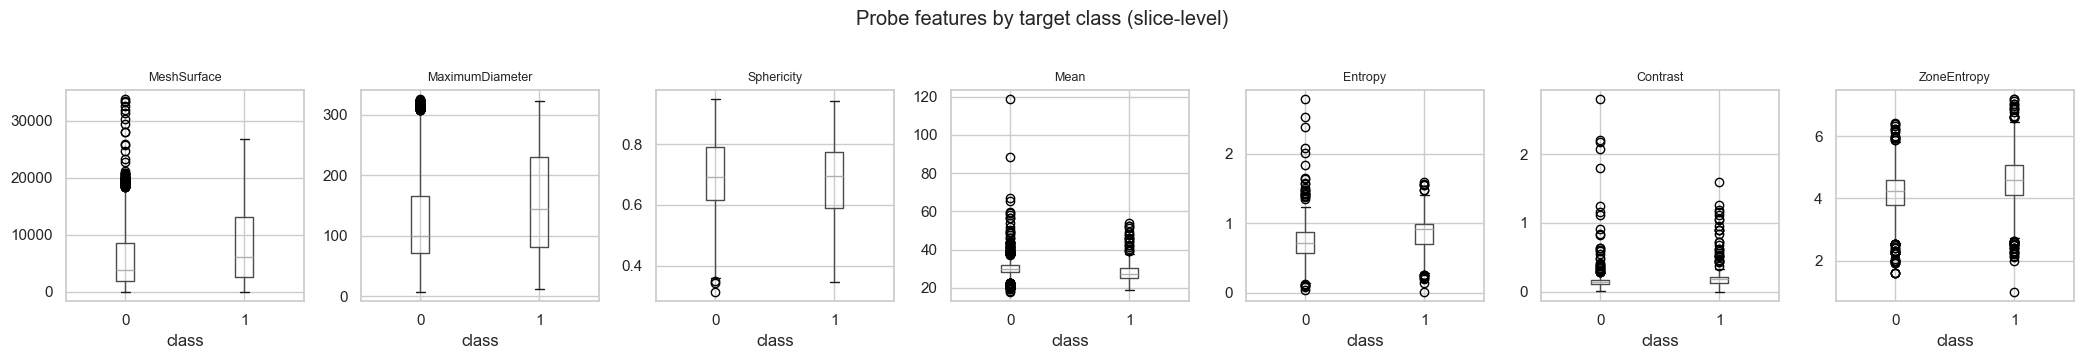

In [ ]:
probe_features = [
    "original_shape2D_MeshSurface",
    "original_shape2D_MaximumDiameter",
    "original_shape2D_Sphericity",
    "original_firstorder_Mean",
    "original_firstorder_Entropy",
    "original_glcm_Contrast",
    "original_glszm_ZoneEntropy",
]


def iqr_outlier_rate(s: pd.Series) -> float:
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((s < lo) | (s > hi)).mean()


sanity = pd.DataFrame(
    {
        "min": df[probe_features].min().round(4),
        "max": df[probe_features].max().round(4),
        "mean": df[probe_features].mean().round(4),
        "n_null": df[probe_features].isna().sum().astype(int),
        "n_negative": (df[probe_features] < 0).sum().astype(int),
        "n_zero": (df[probe_features] == 0).sum().astype(int),
        "outlier_rate_iqr": df[probe_features].apply(iqr_outlier_rate).round(3),
    }
)
print("Sanity check on probe radiomic features:")
print(sanity)

fig, axs = plt.subplots(1, len(probe_features), figsize=(3 * len(probe_features), 3.5), sharey=False)
for ax, feat in zip(axs, probe_features):
    df.boxplot(column=feat, by=target_col, ax=ax)
    ax.set_title(feat.split("_", 2)[-1], fontsize=9)
    ax.set_xlabel("class")
plt.suptitle("Probe features by target class (slice-level)", y=1.02)
plt.tight_layout()
plt.savefig(FIG / "04_probe_features_by_class.png", dpi=120, bbox_inches="tight")
plt.show()

## § 8 — Persistir hallazgos

Escribimos `docs/eda_findings.md` con todos los hallazgos cuantitativos clave. Este documento alimenta:

1. La actualización de `agent.md` §3 (Realidad de los datos).
2. La definición de suites en Great Expectations (Fase 3).
3. Las decisiones de imputación y feature engineering (Fase 5).

El archivo se sobrescribe en cada ejecución del notebook — la **fuente de verdad textual** es este notebook ejecutado, no edición manual del `.md`.

In [ ]:
from datetime import datetime

DOCS = settings.project_root / "docs"
DOCS.mkdir(parents=True, exist_ok=True)
findings_path = DOCS / "eda_findings.md"

train_class = (
    patient_class[patient_class["dataset_origin"] == "train"][target_col].value_counts().to_dict()
)
test_class = (
    patient_class[patient_class["dataset_origin"] == "test"][target_col].value_counts().to_dict()
)

spp_train = slices_per_patient[slices_per_patient["dataset_origin"] == "train"]["n_slices"]
spp_train_min = int(spp_train.min())
spp_train_med = int(spp_train.median())
spp_train_max = int(spp_train.max())

lines = [
    "# EDA Findings — Phase 1 Discovery",
    "",
    f"_Generated automatically by `notebooks/01_data_discovery.ipynb` at {datetime.now():%Y-%m-%d %H:%M}._",
    "",
    "## 1. Grain & cohort",
    f"- Train: **{train.shape[0]} slices**, **{train['ID'].nunique()} unique patients**.",
    f"- Test:  **{test.shape[0]} slices**, **{test['ID'].nunique()} unique patients**.",
    f"- Train↔test patient overlap: **{len(train_ids & test_ids)}** (must be 0).",
    f"- Slices per patient (train): min={spp_train_min}, median={spp_train_med}, max={spp_train_max}.",
    "",
    "## 2. Class balance (patient-level)",
    f"- Train: class_0={train_class.get(0,0)}, class_1={train_class.get(1,0)}.",
    f"- Test:  class_0={test_class.get(0,0)}, class_1={test_class.get(1,0)}.",
    f"- Inconsistent target patients: **{len(inconsistent)}** (must be 0).",
    "",
    "## 3. Missingness (slice-level, train)",
    f"- NIHSS: {int(train['NIHSS'].isna().sum())} ({train['NIHSS'].isna().mean()*100:.1f}%).",
    f"- ASPECTS: {int(train['ASPECTS'].isna().sum())} ({train['ASPECTS'].isna().mean()*100:.1f}%).",
    "- Decision: keep rows; impute with median + add `*_was_missing` indicator in Phase 5.",
    "",
    "## 4. Units & leakage check",
    f"- `Evolution Time` unit inferred: **{UNIT.upper()}** (best cutoff = {best_cut:.2f}, agreement = {best_agree*100:.2f}%).",
    f"- Clinical cutoff (4.5 h) = {270 if UNIT=='minutes' else 4.5} {UNIT}.",
    "- Decision: **drop `Evolution Time` from feature set** (it defines the target arithmetically).",
    "- Decision: in staging, store both `evolution_minutes` (raw) and `evolution_hours` (derived) for clinical reporting only.",
    "",
    "## 5. Demographic drift train ↔ test",
    f"- Sex chi²: p = {p_sex:.4f} ({'DRIFT' if p_sex<0.01 else 'no drift'}).",
    f"- Age KS:   p = {p_age:.4f} ({'DRIFT' if p_age<0.01 else 'no drift'}).",
    "- Decision: report per-subgroup performance in Phase 6; do not stratify training by sex (would leak test priors).",
    "",
    "## 6. Architectural implications confirmed",
    "- **Small-N clinical cohort** (74 unique patients) — DL from scratch is off-limits in v1.",
    "- **GroupKFold on `ID` is mandatory** for all CV.",
    "- **Patient-level aggregation (MIL)** is the path for Phase 5.",
    "- **Class 1 (>4.5h) is the clinically critical minority** — optimize sensitivity, not accuracy.",
    "",
    "## 7. Figures produced",
    "- `reports/figures/01_slices_per_patient.png`",
    "- `reports/figures/02_leakage_evolution_time.png`",
    "- `reports/figures/03_demographic_drift.png`",
    "- `reports/figures/04_probe_features_by_class.png`",
    "",
    "## 8. Next phase entry-conditions",
    "- Data dictionary (`docs/data_dictionary.md`) reflects everything above.",
    "- Ready to design DW (Phase 2): `raw` schema receives CSV as-is; `staging` renames the `Patien` typo and casts numeric columns.",
]

findings_path.write_text("\n".join(lines), encoding="utf-8")
print(f"Wrote {findings_path}")
print()
print("\n".join(lines[:25]))

Wrote C:\Users\andre\Documents\ischemic_stroke_prevention\docs\eda_findings.md

# EDA Findings — Phase 1 Discovery

_Generated automatically by `notebooks/01_data_discovery.ipynb` at 2026-05-25 11:25._

## 1. Grain & cohort
- Train: **1998 slices**, **55 unique patients**.
- Test:  **822 slices**, **19 unique patients**.
- Train↔test patient overlap: **0** (must be 0).
- Slices per patient (train): min=2, median=29, max=117.

## 2. Class balance (patient-level)
- Train: class_0=39, class_1=16.
- Test:  class_0=11, class_1=8.
- Inconsistent target patients: **0** (must be 0).

## 3. Missingness (slice-level, train)
- NIHSS: 198 (9.9%).
- ASPECTS: 169 (8.5%).
- Decision: keep rows; impute with median + add `*_was_missing` indicator in Phase 5.

## 4. Units & leakage check
- `Evolution Time` unit inferred: **MINUTES** (best cutoff = 271.21, agreement = 100.00%).
- Clinical cutoff (4.5 h) = 270 minutes.
- Decision: **drop `Evolution Time` from feature set** (it defines the target arithmeti